In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

data = pd.read_csv("music_survey_cleaned.csv")

Dataset Overview

In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 60 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   timestamp                         736 non-null    object 
 1   age                               736 non-null    float64
 2   primary_streaming_service         736 non-null    object 
 3   hours_per_day                     736 non-null    float64
 4   hours_per_day_capped              736 non-null    float64
 5   hours_per_day_original            736 non-null    float64
 6   hours_outlier_flag                736 non-null    int64  
 7   while_working                     736 non-null    object 
 8   while_working_binary              733 non-null    float64
 9   instrumentalist                   736 non-null    object 
 10  instrumentalist_binary            732 non-null    float64
 11  composer                          736 non-null    object 
 12  composer

In [132]:
data.shape

(736, 60)

In [133]:
data.describe()

,age,hours_per_day,hours_per_day_capped,hours_per_day_original,hours_outlier_flag,while_working_binary,instrumentalist_binary,composer_binary,exploratory_binary,foreign_languages_binary,...,frequency_jazz_score,frequency_k_pop_score,frequency_latin_score,frequency_lofi_score,frequency_metal_score,frequency_pop_score,frequency_randb_score,frequency_rap_score,frequency_rock_score,frequency_video_game_music_score
count,736.000000,736.000000,736.000000,736.000000,736.000000,733.000000,732.000000,735.000000,736.000000,732.000000,...,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000
mean,25.201087,3.572758,3.487160,3.572758,0.013587,0.789905,0.321038,0.171429,0.713315,0.551913,...,1.027174,0.735054,0.607337,1.067935,1.220109,2.031250,1.259511,1.335598,2.070652,1.250000
std,12.047764,3.028199,2.634599,3.028199,0.115847,0.407654,0.467195,0.377140,0.452521,0.497638,...,0.938559,1.002945,0.864666,1.027912,1.134698,0.934801,1.058451,1.053732,1.034327,1.071587
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,21.000000,3.000000,3.000000,3.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000
75%,28.000000,5.000000,5.000000,5.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000
max,89.000000,24.000000,12.000000,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000


In [134]:
data.head(20)

,timestamp,age,primary_streaming_service,hours_per_day,hours_per_day_capped,hours_per_day_original,hours_outlier_flag,while_working,while_working_binary,instrumentalist,...,frequency_jazz_score,frequency_k_pop_score,frequency_latin_score,frequency_lofi_score,frequency_metal_score,frequency_pop_score,frequency_randb_score,frequency_rap_score,frequency_rock_score,frequency_video_game_music_score
0,2022-08-27 19:29:02,18.0,Spotify,3.0,3.0,3.0,0,Yes,1.0,Yes,...,0.0,3.0,3.0,1.0,0.0,3.0,2.0,3.0,0.0,2.0
1,2022-08-27 19:57:31,63.0,Pandora,1.5,1.5,1.5,0,Yes,1.0,No,...,3.0,1.0,2.0,1.0,0.0,2.0,2.0,1.0,3.0,1.0
2,2022-08-27 21:28:18,18.0,Spotify,4.0,4.0,4.0,0,No,0.0,No,...,1.0,3.0,0.0,2.0,2.0,1.0,0.0,1.0,1.0,3.0
3,2022-08-27 21:40:40,61.0,YouTube Music,2.5,2.5,2.5,0,Yes,1.0,No,...,3.0,2.0,3.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0
4,2022-08-27 21:54:47,18.0,Spotify,4.0,4.0,4.0,0,Yes,1.0,No,...,0.0,3.0,2.0,2.0,0.0,2.0,3.0,3.0,0.0,1.0
5,2022-08-27 21:56:50,18.0,Spotify,5.0,5.0,5.0,0,Yes,1.0,Yes,...,3.0,3.0,1.0,3.0,1.0,3.0,3.0,3.0,3.0,0.0
6,2022-08-27 22:00:29,18.0,YouTube Music,3.0,3.0,3.0,0,Yes,1.0,Yes,...,2.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0
7,2022-08-27 22:18:59,21.0,Spotify,1.0,1.0,1.0,0,Yes,1.0,No,...,1.0,3.0,0.0,2.0,0.0,2.0,2.0,1.0,0.0,1.0
8,2022-08-27 22:33:05,19.0,Spotify,6.0,6.0,6.0,0,Yes,1.0,No,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0
9,2022-08-27 22:44:03,18.0,I do not use a streaming service.,1.0,1.0,1.0,0,Yes,1.0,No,...,1.0,0.0,1.0,1.0,0.0,2.0,2.0,1.0,2.0,2.0


Conversion of data types to right format; age should be converted to integer format for this dataset

In [135]:
# converting the "age" column to integer type
data["age"]=data["age"].astype('Int64')

In [136]:
# Checking to see if the "age" column has been converted to integer type
data['age'].dtype
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 60 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   timestamp                         736 non-null    object 
 1   age                               736 non-null    Int64  
 2   primary_streaming_service         736 non-null    object 
 3   hours_per_day                     736 non-null    float64
 4   hours_per_day_capped              736 non-null    float64
 5   hours_per_day_original            736 non-null    float64
 6   hours_outlier_flag                736 non-null    int64  
 7   while_working                     736 non-null    object 
 8   while_working_binary              733 non-null    float64
 9   instrumentalist                   736 non-null    object 
 10  instrumentalist_binary            732 non-null    float64
 11  composer                          736 non-null    object 
 12  composer

Data Cleaning

In [137]:
# Assessing the dataset for missing values

data.isna().sum()

timestamp                             0
age                                   0
primary_streaming_service             0
hours_per_day                         0
hours_per_day_capped                  0
hours_per_day_original                0
hours_outlier_flag                    0
while_working                         0
while_working_binary                  3
instrumentalist                       0
instrumentalist_binary                4
composer                              0
composer_binary                       1
fav_genre                             0
exploratory                           0
exploratory_binary                    0
foreign_languages                     0
foreign_languages_binary              4
bpm                                   0
bpm_original                        107
bpm_invalid_flag                      0
anxiety                               0
depression                            0
insomnia                              0
ocd                                   0


In [138]:
# Calculate missing values per column and sort them in descending order
missing_priority = data.isna().sum().sort_values(ascending=False)

# Display only the columns that have at least 1 missing value
print(missing_priority[missing_priority > 0])

bpm_original                107
foreign_languages_binary      4
instrumentalist_binary        4
while_working_binary          3
composer_binary               1
dtype: int64


In [139]:
Missing_columns=data.columns[data.isna().any()].tolist()
print("Columns with missing values:", Missing_columns)

Columns with missing values: ['while_working_binary', 'instrumentalist_binary', 'composer_binary', 'foreign_languages_binary', 'bpm_original']


For the column with 107 missing values(B) (~14.5% missing)
Since 14.5% is a significant chunk but well under the 30% danger zone, I would not drop the column. Dropping it would cause us to lose the 85.5% of perfectly good data in it.
So therefore, it would be filled with the median values.

In [140]:
# Fill the column with 107 missing values using its median
# (Replace 'your_column_with_107' with the actual column name from your dataset)
target_col = 'bpm_original' 
data[target_col] = data[target_col].fillna(data[target_col].median())

When analyzing this dataset, a subset of columns (while_working_binary, instrumentalist_binary, composer_binary, and foreign_languages_binary) was found to contain an exceptionally small number of missing records—ranging from only 1 to 4 missing values per column.

Given our baseline dataset size of 736 rows, the total missing data across these columns constitutes less than 0.5% of our total sample size.

Removing these rows entirely—rather than guessing the missing values—leaves us with a clean, unmanipulated dataset.

In [141]:
# Define the target columns identified with low missing-value counts (<0.5%)
low_missing_cols = [
    'while_working_binary', 
    'instrumentalist_binary', 
    'composer_binary', 
    'foreign_languages_binary'
]


data.dropna(subset=low_missing_cols, inplace=True)


print(f"Data cleaning successful. Post-drop dataset shape: {data.shape}")

Data cleaning successful. Post-drop dataset shape: (727, 60)


In [142]:
data.isna().sum()

timestamp                           0
age                                 0
primary_streaming_service           0
hours_per_day                       0
hours_per_day_capped                0
hours_per_day_original              0
hours_outlier_flag                  0
while_working                       0
while_working_binary                0
instrumentalist                     0
instrumentalist_binary              0
composer                            0
composer_binary                     0
fav_genre                           0
exploratory                         0
exploratory_binary                  0
foreign_languages                   0
foreign_languages_binary            0
bpm                                 0
bpm_original                        0
bpm_invalid_flag                    0
anxiety                             0
depression                          0
insomnia                            0
ocd                                 0
mental_health_self_report_avg       0
music_effect

Data Cleaning Completed: There are no missing values in the dataset.

Data Visualization

Text(0.5, 1.0, 'Distribution of Age')

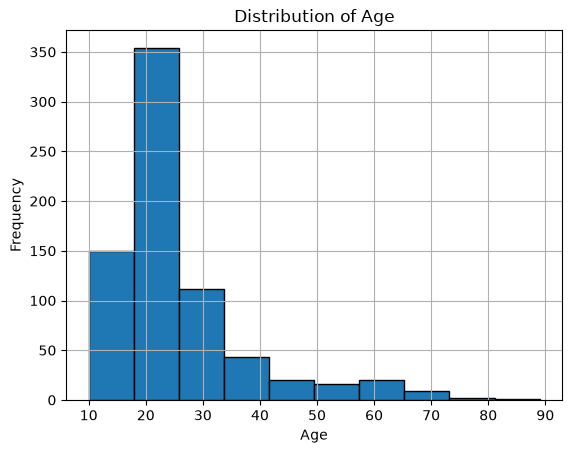

In [143]:
data["age"].hist(bins=10, edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")

Text(0, 0.5, 'Count')

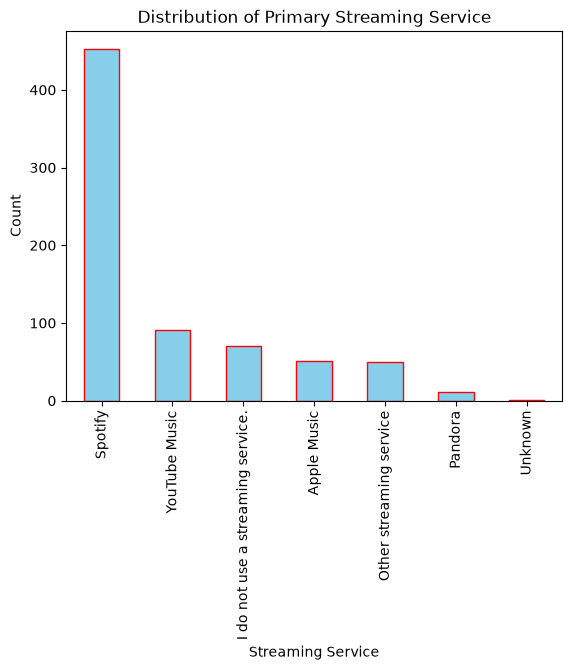

In [144]:
data["primary_streaming_service"].value_counts().plot(kind='bar', color='skyblue', edgecolor='red')
plt.title("Distribution of Primary Streaming Service")
plt.xlabel("Streaming Service")
plt.ylabel("Count")


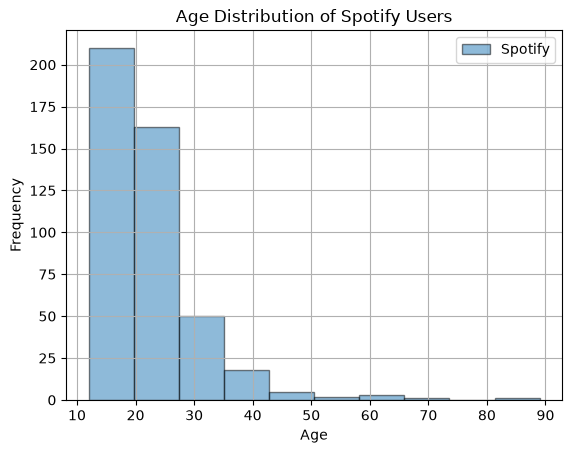

In [145]:
data[data['primary_streaming_service'] == 'Spotify']['age'].hist(bins=10, edgecolor='black', alpha=0.5, label='Spotify')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution of Spotify Users")
plt.legend()
plt.show()


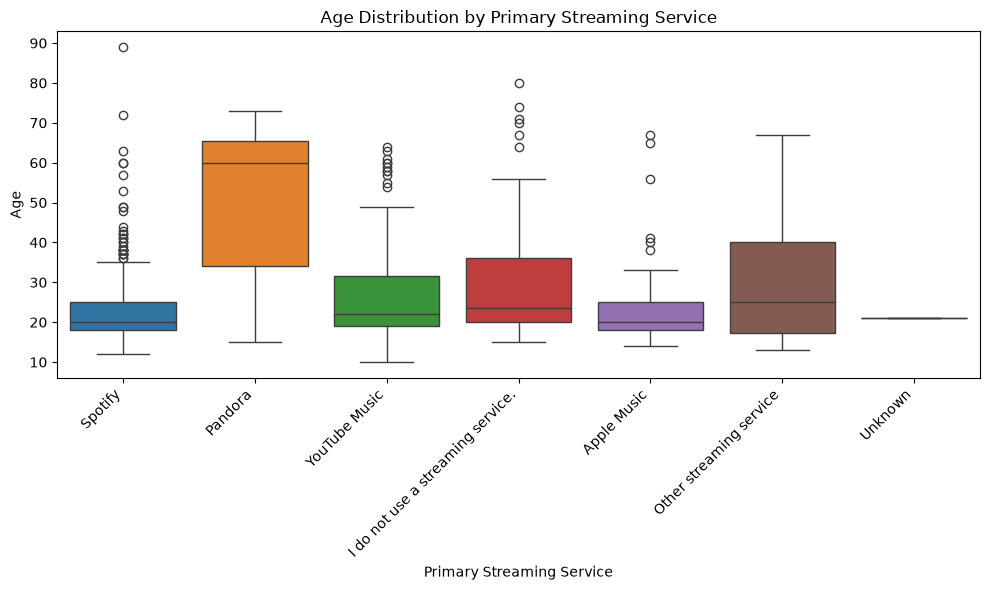

In [146]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='primary_streaming_service', y='age', data=data, hue='primary_streaming_service')
plt.title("Age Distribution by Primary Streaming Service")
plt.ylabel("Age")
plt.xlabel("Primary Streaming Service")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


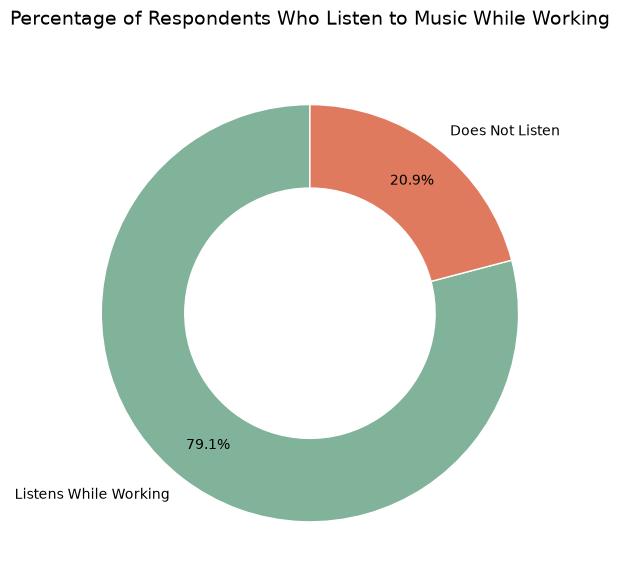

In [147]:
plt.figure(figsize=(6, 6))
work_counts = data['while_working_binary'].value_counts()
labels = ['Listens While Working', 'Does Not Listen']
plt.pie(work_counts, labels=labels, autopct='%1.1f%%', startangle=90,
        pctdistance=0.80, colors=['#81B29A', '#E07A5F'], wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Percentage of Respondents Who Listen to Music While Working', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

/var/folders/_n/5jqwy0bx12j2x2dghjm2qbjr0000gn/T/ipykernel_1803/2864365898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='foreign_languages_binary', y='frequency_pop_score',


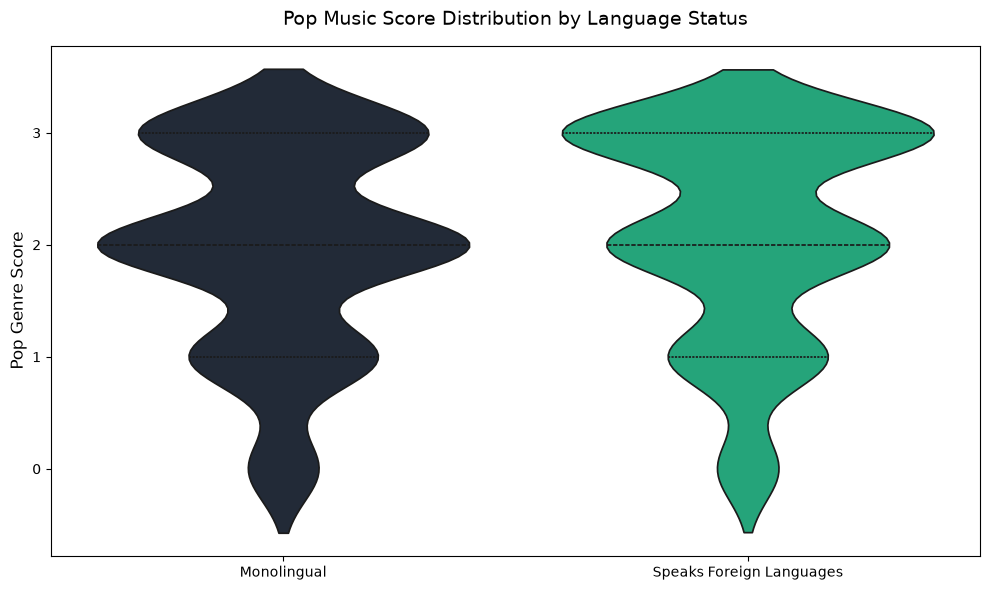

In [148]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='foreign_languages_binary', y='frequency_pop_score', 
               palette=['#1E293B', '#10B981'], inner='quartile')
plt.xticks(ticks=[0, 1], labels=['Monolingual', 'Speaks Foreign Languages'])
plt.title('Pop Music Score Distribution by Language Status', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Pop Genre Score', fontsize=12)
plt.tight_layout()
plt.show()

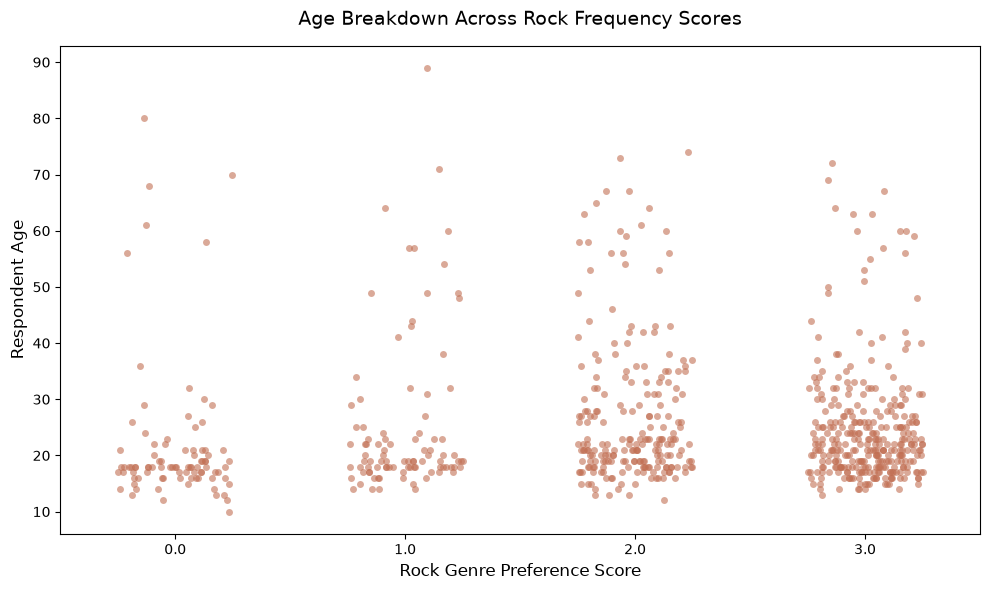

In [149]:
plt.figure(figsize=(10, 6))

sns.stripplot(data=data, x='frequency_rock_score', y='age', 
              jitter=0.25, size=5, color='#C27054', alpha=0.6)
plt.title('Age Breakdown Across Rock Frequency Scores', fontsize=14, pad=15)
plt.xlabel('Rock Genre Preference Score', fontsize=12)
plt.ylabel('Respondent Age', fontsize=12)
plt.tight_layout()
plt.show()

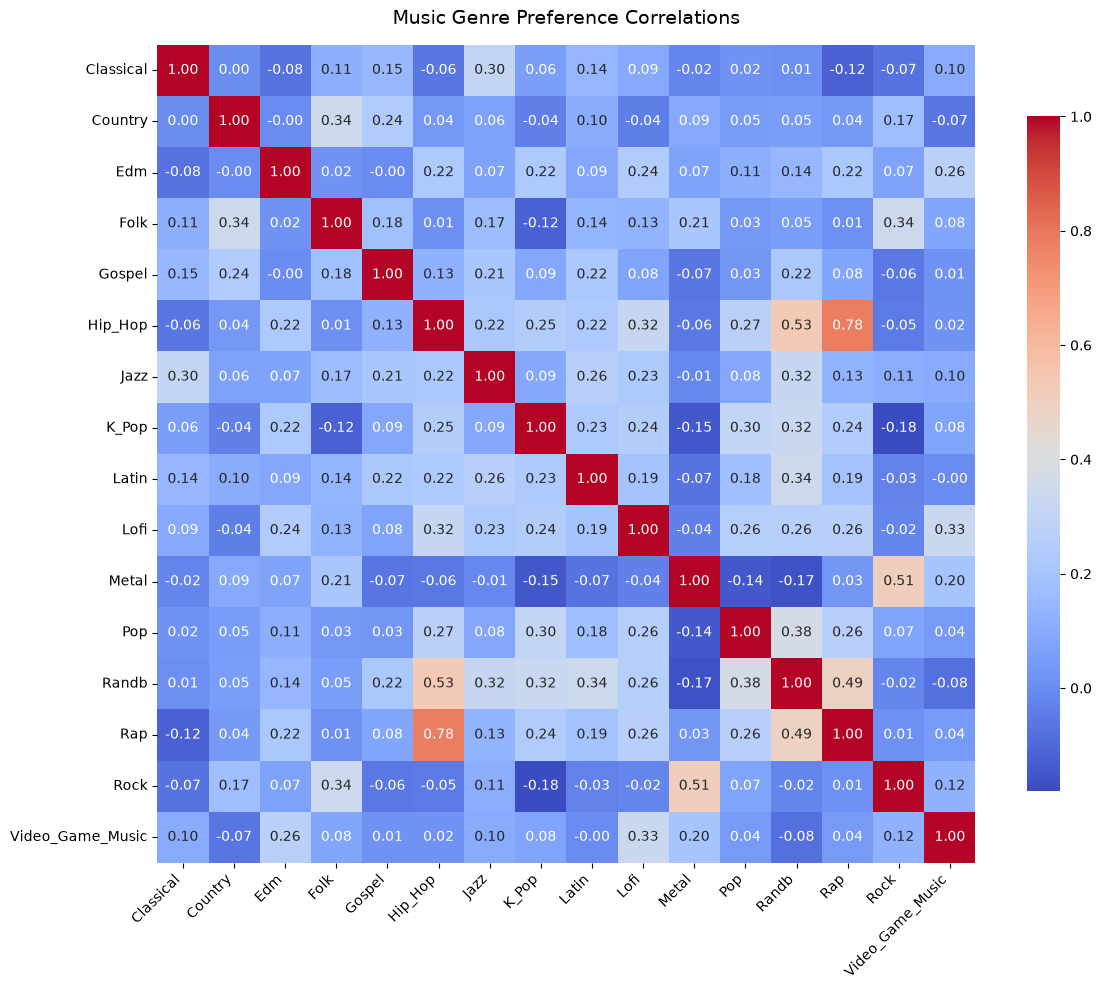

In [150]:

plt.figure(figsize=(12, 10))

# Filter to get just the core score variables
genre_cols = [col for col in data.columns if col.endswith('_score')]
correlation_matrix = data[genre_cols].corr()

# Clean up column names for readability in the chart grid lines
short_labels = [col.replace('frequency_', '').replace('_score', '').title() for col in genre_cols]

# Draw a beautiful, smooth correlation heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            xticklabels=short_labels, yticklabels=short_labels, square=True, cbar_kws={"shrink": .8})

plt.title('Music Genre Preference Correlations', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

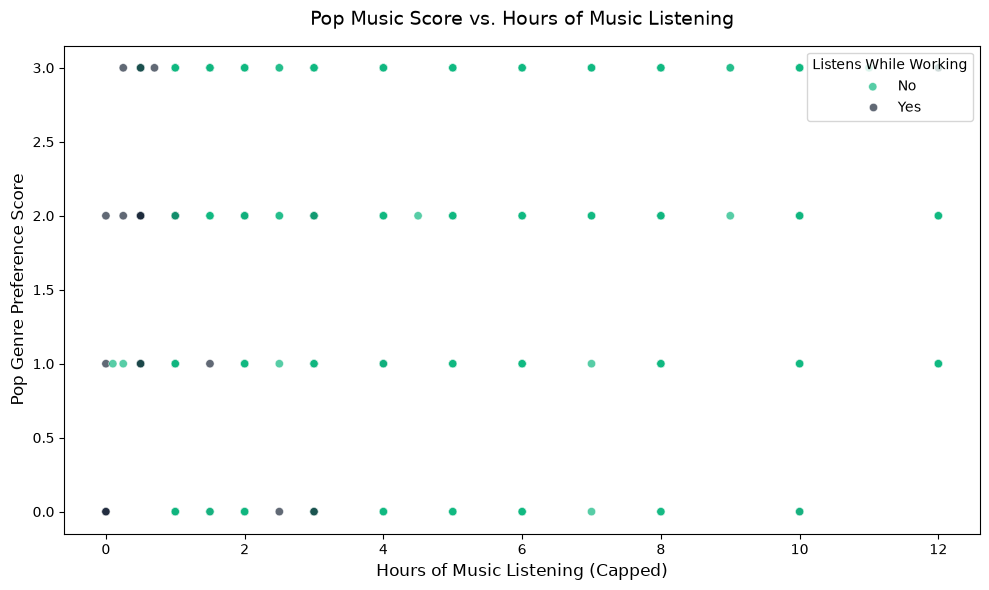

In [151]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='hours_per_day_capped', y='frequency_pop_score', hue='while_working_binary', palette=['#1E293B', '#10B981'], alpha=0.7)
plt.title('Pop Music Score vs. Hours of Music Listening', fontsize=14, pad=15)
plt.xlabel('Hours of Music Listening (Capped)', fontsize=12)
plt.ylabel('Pop Genre Preference Score', fontsize=12)
plt.legend(title='Listens While Working', labels=['No', 'Yes'], loc='upper right')
plt.tight_layout()
plt.show()